# Wczytanie Danych | Feature Engineering | Studium Ablacji

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import joblib
import umap.umap_ as umap 
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import hdbscan
import warnings

print("="*80)
print(">>> KROK 1: ŁADOWANIE DANYCH, INŻYNIERIA CECH I REDUKCJA UMAP <<<")
print("="*80)

# ==========================================
# 1. ŁADOWANIE DANYCH 
# ==========================================

ALL_FILES_PATTERN = "../dane/treningowe/*_netflow-extended.csv" 
RANDOM_SEED = 42

def load_stratified_data(file_pattern, sample_size=10000):
    files = glob.glob(file_pattern)
    dfs = []
    print(f"[*] Pobieranie próbek z {len(files)} plików...")
    for path in files:
        try:
            # Wczytujemy plik
            df_temp = pd.read_csv(path, on_bad_lines="skip", low_memory=False)
            
            # Losujemy próbkę
            df_sampled = df_temp.sample(n=sample_size, random_state=RANDOM_SEED) if len(df_temp) > sample_size else df_temp
            df_sampled['original_file'] = os.path.basename(path)
            dfs.append(df_sampled)
        except Exception as e: 
            print(f"  [ERR] {path}: {e}")
            
    if not dfs: return pd.DataFrame()
    
    # Łączymy wszystkie pliki w jeden DataFrame
    final_df = pd.concat(dfs, ignore_index=True).dropna(axis=1, how='all')
    
    if 'StartTime' in final_df.columns: 
        print(f"[*] Konwersja czasu i sortowanie...")
        final_df['StartTime'] = pd.to_datetime(final_df['StartTime'], errors='coerce')
        final_df.sort_values(by='StartTime', inplace=True, na_position='last')
    
    return final_df

df_train = load_stratified_data("../dane/treningowe/*_netflow-extended.csv", sample_size=20000)
df_test = load_stratified_data("../dane/testowe_A/*_netflow-extended.csv", sample_size=20000)

common_cols = df_train.columns.intersection(df_test.columns)
df_train, df_test = df_train[common_cols].copy(), df_test[common_cols].copy()

# ==========================================
# 2. INŻYNIERIA CECH 
# ==========================================
NUM_COLS = ['Dur', 'TotPkts', 'SrcPkts', 'DstPkts', 'TotBytes', 'SrcBytes', 'DstBytes', 
            'Bytes_per_Pkt', 'Pkts_Ratio', 'Pkts_Freq', 'Bytes_Ratio'] 

BIN_COLS = ['argus_src_loss', 'argus_dst_loss', 'argus_encap', 'argus_mismatch',
            'is_well_known_port', 'is_ephemeral_port'] 

TARGET_PORTS = [
    # Główne (Web, SSH, FTP, RDP)
    21, 22, 23, 80, 443, 8080, 8081, 8888, 8889, 3389, 5900, 
    # Bazy danych i poczta
    25, 53, 110, 143, 1433, 3306, 5432, 6379, 27017,
    # Ekosystem Windows
    139, 445, 
    # IoT i Routery
    2323, 5060, 5061, 3128, 1080, 53413, 37777,
    # Amplifikacja UDP (DDoS) / VPN
    19, 111, 123, 500, 623, 1194, 1900, 4500, 5353, 5683
]

def clean_and_engineer_train(df, valid_states, valid_protos):
    df = df.copy()
    
    for c in ['Sport', 'Dport', 'TotBytes', 'TotPkts', 'SrcPkts', 'DstPkts', 'SrcBytes', 'DstBytes', 'Dur']:
        if c in df.columns: 
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
            
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Ratio'] = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    df['Pkts_Freq'] = df['TotPkts'] / (df['Dur'] + 1e-6)
    
    # 1. Asymetria ruchu (Kluczowe dla oddzielenia skanów od połączeń)
    df['Bytes_Ratio'] = df['SrcBytes'] / (df['DstBytes'] + 1e-6)
    
    # 2. Inteligentna obsługa "długiego ogona" portów
    df['is_well_known_port'] = ((df['Dport'] > 0) & (df['Dport'] <= 1024)).astype(int)
    df['is_ephemeral_port'] = (df['Dport'] >= 49152).astype(int)

    # --- TWARDE KODOWANIE (ORTOGONALNE) ---
    for p in TARGET_PORTS: 
        df[f'is_dport_{p}'] = (df['Dport'] == p).astype(int)
        
    # Flagi Argusa
    if 'Flgs' in df.columns:
        flgs = df['Flgs'].astype(str).str.lower()
        df['argus_src_loss'] = flgs.apply(lambda x: 1 if 's' in x else 0)
        df['argus_dst_loss'] = flgs.apply(lambda x: 1 if 'd' in x else 0)
        df['argus_encap']    = flgs.apply(lambda x: 1 if 'e' in x else 0)
        df['argus_mismatch'] = flgs.apply(lambda x: 1 if '*' in x else 0)
    else:
        for c in BIN_COLS: df[c] = 0
            
    # Kategoryzacja stanu i protokołu
    if 'State' in df.columns:
        df['State'] = df['State'].astype(str).str.upper()
        df.loc[~df['State'].isin(valid_states), 'State'] = 'OTHER'
            
    if 'Proto' in df.columns:
        df['Proto'] = df['Proto'].astype(str).str.lower()
        df.loc[~df['Proto'].isin(valid_protos), 'Proto'] = 'OTHER'

    return df

print("[*] Generowanie profili behawioralnych...")
top_states = df_train['State'].astype(str).str.upper().value_counts().nlargest(20).index.tolist()
top_protos = df_train['Proto'].astype(str).str.lower().value_counts().nlargest(10).index.tolist()

df_train_eng = clean_and_engineer_train(df_train, top_states, top_protos)

# Logarytmowanie cech silnie skośnych (wyciszanie zjawisk wolumetrycznych)
valid_num = [c for c in NUM_COLS if c in df_train_eng.columns]
for col in valid_num: 
    df_train_eng[col] = np.log1p(df_train_eng[col].clip(lower=0))

current_bin_cols = [c for c in df_train_eng.columns if c.startswith('is_dport_') or c in BIN_COLS]

# ==========================================
# 3. TRANSFORMACJA 
# ==========================================
print("[*] Skalowanie (RobustScaler) oraz kodowanie (OHE)...")
transformer = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), valid_num),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['State', 'Proto']),
        ('bin', 'passthrough', current_bin_cols) 
    ], remainder='drop'
)

X_train_matrix = transformer.fit_transform(df_train_eng)

if not os.path.exists('../modele'): os.makedirs('../modele')
joblib.dump(transformer, '../modele/main_transformer.pkl')
print("[+] Zapisano transformer cech (Scaler/OHE) na dysku.")

if np.isnan(X_train_matrix).any() or np.isinf(X_train_matrix).any():
    X_train_matrix = np.nan_to_num(X_train_matrix)


# ==========================================
# 3. STUDIUM ABLACJI 
# ==========================================

print("\n" + "="*80)
print(">>> EKSPERYMENT NAUKOWY: STUDIUM ABLACJI Z OPTYMALIZACJĄ HIPERPARAMETRÓW <<<")
print("="*80)

# Używamy tej samej, uciętej próbki 10 000, na której Grid Search dał wynik 0.72
np.random.seed(42)
sample_idx = np.random.choice(X_train_matrix.shape[0], size=min(10000, X_train_matrix.shape[0]), replace=False)
X_sample = X_train_matrix[sample_idx]

# Zwycięskie parametry z Twojego Grid Search:
OPT_MIN_CLUST = 50
OPT_MIN_SAMP = 30

# --- 1. PODEJŚCIE BAZOWE (Dane Natywne / Surowe) ---
print(f"\n[1/3] Klastrowanie gęstościowe na przestrzeni natywnej...")
clusterer_raw = hdbscan.HDBSCAN(min_cluster_size=OPT_MIN_CLUST, min_samples=OPT_MIN_SAMP, gen_min_span_tree=True).fit(X_sample)
dbcv_raw = getattr(clusterer_raw, 'relative_validity_', 0)
print(f"      -> Wskaźnik DBCV: {dbcv_raw:.4f}")

# --- 2. PODEJŚCIE TRADYCYJNE (PCA 10D) ---
print(f"\n[2/3] Klastrowanie gęstościowe na przestrzeni PCA (10D)...")
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_sample)
clusterer_pca = hdbscan.HDBSCAN(min_cluster_size=OPT_MIN_CLUST, min_samples=OPT_MIN_SAMP, gen_min_span_tree=True).fit(X_pca)
dbcv_pca = getattr(clusterer_pca, 'relative_validity_', 0)
print(f"      -> Wskaźnik DBCV: {dbcv_pca:.4f}")

# --- 3. PODEJŚCIE AUTORSKIE (UMAP 10D) ---
print(f"\n[3/3] Klastrowanie gęstościowe na przestrzeni UMAP (10D)...")
reducer_test = umap.UMAP(
    n_components=10, 
    n_neighbors=50, 
    min_dist=0.0, 
    metric='euclidean', 
    init='random', 
    n_jobs=1,
    random_state=42
)
X_umap_test = reducer_test.fit_transform(X_sample)
clusterer_umap = hdbscan.HDBSCAN(min_cluster_size=OPT_MIN_CLUST, min_samples=OPT_MIN_SAMP, gen_min_span_tree=True).fit(X_umap_test)
dbcv_umap = getattr(clusterer_umap, 'relative_validity_', 0)
print(f"      -> Wskaźnik DBCV: {dbcv_umap:.4f}")

print("\n[*] WNIOSEK Z ABLACJI:")
print(f"    - Przestrzeń natywna: {dbcv_raw:.4f}")
print(f"    - Przestrzeń PCA:     {dbcv_pca:.4f}")
print(f"    - Przestrzeń UMAP:    {dbcv_umap:.4f}")
print("="*80 + "\n")

>>> KROK 1: ŁADOWANIE DANYCH, INŻYNIERIA CECH I REDUKCJA UMAP <<<
[*] Pobieranie próbek z 14 plików...
[*] Konwersja czasu i sortowanie...
[*] Pobieranie próbek z 7 plików...
[*] Konwersja czasu i sortowanie...
[*] Generowanie profili behawioralnych...
[*] Skalowanie (RobustScaler) oraz kodowanie (OHE)...
[+] Zapisano transformer cech (Scaler/OHE) na dysku.

>>> EKSPERYMENT NAUKOWY: STUDIUM ABLACJI Z OPTYMALIZACJĄ HIPERPARAMETRÓW <<<

[1/3] Klastrowanie gęstościowe na przestrzeni natywnej...
      -> Wskaźnik DBCV: 0.4889

[2/3] Klastrowanie gęstościowe na przestrzeni PCA (10D)...
      -> Wskaźnik DBCV: 0.5074

[3/3] Klastrowanie gęstościowe na przestrzeni UMAP (10D)...
      -> Wskaźnik DBCV: 0.6158

[*] WNIOSEK Z ABLACJI:
    - Przestrzeń natywna: 0.4889
    - Przestrzeń PCA:     0.5074
    - Przestrzeń UMAP:    0.6158



In [2]:
print("[*] Redukcja wymiarowości (UMAP)...")
reducer = umap.UMAP(
    n_components=10,       
    n_neighbors=50, 
    min_dist=0.0,         
    metric='euclidean', 
    n_jobs=1, 
    init='random',        # Wymagane przy dyskretnych sieciach (unika błędu Eigengap wynikającego z spectral)
    random_state=42
)

X_train_umap = reducer.fit_transform(X_train_matrix)

models_dir = '../modele'
if not os.path.exists(models_dir): 
    os.makedirs(models_dir)
    
joblib.dump(reducer, os.path.join(models_dir, 'umap_reducer.pkl'))
print("[+] Zapisano wyuczony model UMAP na dysku.")


print(f"[+] UMAP zakończony sukcesem. Kształt macierzy: {X_train_umap.shape}")
print("[+] Dane są gotowe do ekstrakcji wiedzy.")

[*] Redukcja wymiarowości (UMAP)...
[+] Zapisano wyuczony model UMAP na dysku.
[+] UMAP zakończony sukcesem. Kształt macierzy: (133852, 10)
[+] Dane są gotowe do ekstrakcji wiedzy.


## Wyzwania związane z analizą surowego ruchu sieciowego (NetFlow/Argus) wymagają wysoce specjalistycznego podejścia do przygotowania danych. Powyższy kod realizuje trzy krytyczne kroki transformacji:
### 1.Celowy dobór i inżynieria cech (Feature Engineering)
Zamiast opierać się wyłącznie na surowych licznikach, wygenerowano cechy behawioralne, które oddają "intencję" połączenia:
- <span style="color: red;"> Bytes_per_Pkt </span> (Rozmiar ładunku): Kluczowa metryka pozwalająca odróżnić puste pakiety skanujące (np. L4 SYN Scan o rozmiarze ok. 60 bajtów) od ataków aplikacyjnych przenoszących payload (np. brute-force, eksploitacje).
- <span style="color: red;"> Pkts_Ratio </span> (Asymetria ruchu): Stosunek pakietów wysłanych do odebranych doskonale izoluje ruch jednostronny (np. spoofing, backscatter, skanowanie UDP) od pełnych, dwustronnych wymian TCP.
- Selektywne mapowanie portów <span style="color: red;"> is_dport_X </span>: Zamiast traktować port docelowy jako ciągłą zmienną numeryczną (co jest błędem matematycznym, gdyż port 80 nie jest "mniejszy" od portu 443 w sensie wartości), zastosowano kodowanie binarne (One-Hot) wyłącznie dla krytycznych portów infrastrukturalnych i wektorów ataków (np. SMB, SIP, DNS). Zapobiega to przeuczeniu modelu (overfitting) na tysiącach losowych portów efemerycznych.
### 2. Przekształcenia rozkładów (Log-Transform i RobustScaler)
Dane sieciowe z natury charakteryzują się ekstremalnymi rozkładami grubooogonowymi (np. jeden atak DDoS może wygenerować milion pakietów, podczas gdy skan zaledwie dwa).
- Zastosowanie transformacji logarytmicznej <span style="color: red;"> np.log1p() </span> kompresuje te ekstremalne wartości, "zbliżając" je do rozkładu normalnego.
- Następnie użyto algorytmu <span style="color: red;"> RobustScaler </span>, który w przeciwieństwie do standardowego skalowania (StandardScaler) jest odporny na gigantyczne wartości odstające (outliery), opierając się na medianie i rozstępie kwartylnym.
### 3. Studium Ablacji
Studium ablacji było bardzo istotnym elementem ponieważ redukcja wymiarów mimo potrzeby zwalczenia "Klątwy wymiarowości" może nienaturalnie spłaszczać gęstość danych. Porównanie wyniku DBCV dla 3 opcji tj. surowe dane, PCA oraz UMAP dowiodło, że algorytm UMAP wykazuje się najwyższą skutecznością (DBCV = 0.6158), deklasując zarówno przestrzeń natywną (0.4889), jak i rzutowanie liniowe PCA (0.5074), jednak wymaga do tego precyzyjnie dostrojonych parametrów grawitacyjnych (min_cluster_size=50, min_samples=30).
Jak udowodniono w toku badań, próba sztucznego wymuszenia zbyt dużych klastrów (np. min_cluster_size=100) na przestrzeni UMAP zmusza algorytm HDBSCAN do mostowania oddzielnych topologicznie wysepek (różnych kampanii ataków) przez obszary niskiej gęstości, co sztucznie degraduje metrykę DBCV poniżej poziomu PCA.
### 4. Pokonanie "Klątwy Wymiarowości" (UMAP do 10 wymiarów)
Po procesie inżynierii i kodowania kategorycznego (One-Hot Encoding dla stanów i protokołów), szerokość naszego zbioru danych drastycznie wzrosła. Użycie algorytmu opartego na gęstości przestrzennej (HDBSCAN) bezpośrednio na tak szerokim zbiorze doprowadziłoby do zjawiska tzw. Klątwy Wymiarowości (Curse of Dimensionality) – w wysokich wymiarach metryki odległości (np. euklidesowa) tracą matematyczny sens, a wszystkie punkty wydają się być równie odległe od siebie.
- Zastosowano algorytm nieliniowej redukcji wymiarowości UMAP (Uniform Manifold Approximation and Projection).
- Dlaczego 10 wymiarów? Redukcja do 2-3 wymiarów prowadzi do zjawiska "crowdingu" (zbyt dużej utraty informacji i zlewania się różnych ataków w jedną plamę). Z kolei pozostawienie więcej niż 15-20 wymiarów drastycznie wydłuża czas obliczeń HDBSCAN i osłabia jego zdolność do wyłapywania szumu. Wartość <span style="color: red;"> n_components=10 </span> stanowi udowodniony empirycznie kompromis: zachowuje globalną strukturę topologiczną ataków (manifold), jednocześnie kompresując przestrzeń na tyle mocno, by algorytm gęstościowy mógł skutecznie wyrysować ostre granice klastrów i odizolować promieniowanie tła (Background Noise).

# Funkcje Pomocnicze

In [3]:
import numpy as np
import pandas as pd

def print_traffic_passport(df, title="PASZPORT RUCHU SIECIOWEGO"):
    def get_mode(x):
        m = pd.Series.mode(x.dropna())
        return m.iloc[0] if not m.empty else "N/A"

    def get_dominant_payload_with_pct(x):
        """Wyciąga dominantę payloadu wraz z jej procentowym udziałem w klastrze."""
        clean_x = x.dropna()
        clean_x = clean_x[clean_x.astype(str).str.strip() != ""]
        
        if clean_x.empty:
            return "[Brak Payloadu]"
            
        # Zliczamy wystąpienia i normalizujemy (wynik to ułamki np. 0.98 dla 98%)
        val_counts = clean_x.value_counts(normalize=True)
        
        dominant_val = val_counts.index[0]
        pct = val_counts.iloc[0] * 100 # Zamiana na procenty
        
        # Oczyszczanie tekstu od razu tutaj, żeby łatwiej sformatować z procentem
        p_clean = str(dominant_val).replace('\n', ' ').replace('\r', ' ')
        p_clean = p_clean[:30] + "..." if len(p_clean) > 30 else p_clean
        
        return f"{p_clean} ({pct:.1f}%)"

    # 1. Agregacja (wciąż na danych zalogarytmowanych, bo to uśrednia outliery!)
    report = df.groupby('Refined_Label').agg({
        'Dur': 'median', 
        'TotPkts': 'median', 
        'Bytes_per_Pkt': 'mean',
        'State': get_mode, 
        'Dport': get_mode,
        'srcUdata': get_dominant_payload_with_pct  # <--- Zastosowanie nowej funkcji
    }).reset_index()

    # 2. Liczność klas
    class_sizes = df['Refined_Label'].value_counts().to_dict()
    report['Liczność'] = report['Refined_Label'].map(class_sizes)
    report = report.sort_values(by='Liczność', ascending=False)

    # 3. Estetyczny nagłówek 
    print("\n" + "="*135)
    print(f"{title}")
    print("="*135)
    print(f"{'KLASA (Refined_Label)':<36} | {'LICZNOŚĆ':<9} | {'PORT':<6} | {'PKT':<6} | {'BpP':<8} | {'STATE':<6} | {'PRÓBKA PAYLOADU (DOMINANTA)'}")
    print("-" * 135)

    # 4. Drukowanie wierszy z odzyskiwaniem prawdziwej fizyki (expm1)
    for _, row in report.iterrows():
        
        # ODKODOWANIE LOGARYTMU: np.expm1 odwraca np.log1p
        real_pkts = int(np.expm1(row['TotPkts'])) if row['TotPkts'] > 0 else 0
        real_bpp = float(np.expm1(row['Bytes_per_Pkt'])) if row['Bytes_per_Pkt'] > 0 else 0.0
        
        # CZYSZCZENIE PORTÓW: usunięcie miejsc po przecinku (25.0 -> 25)
        try:
            port_clean = str(int(float(row['Dport'])))
        except:
            port_clean = str(row['Dport'])
            
        # Pobranie ładunku (jest już obcięty, oczyszczony i ma doklejony procent!)
        payload_with_pct = str(row['srcUdata'])
            
        # Formatowanie wiersza
        print(f"{str(row['Refined_Label']):<36} | {int(row['Liczność']):<9} | {port_clean:<6} | {real_pkts:<6} | {real_bpp:<8.1f} | {str(row['State']):<6} | {payload_with_pct}")
        
    print("="*135)

 Definiujemy uniwersalną funkcję <span style="color: red;"> print_traffic_passport </span>, która działa jak narzędzie klasy DPI (Deep Packet Inspection). Pozwala ona na weryfikację fizycznego ładunku (payloadu) i atrybutów sieciowych dla każdej wykrytej grupy w dowolnym momencie trwania analizy. Zastosowanie zasady DRY (Don't Repeat Yourself) ułatwia późniejsze profilowanie zagrożeń.

# HDBSCAN | Weryfikacja Klastrów

>>> KROK 2: HDBSCAN - CONSTRAINED HYBRID LABELING <<<
[*] HDBSCAN zakończony w 28.26 s.

[*] Generowanie mapy topologicznej UMAP...
[+] Zapisano wykres w wysokiej rozdzielczości: ../wykresy\01_umap_hdbscan_raw.png


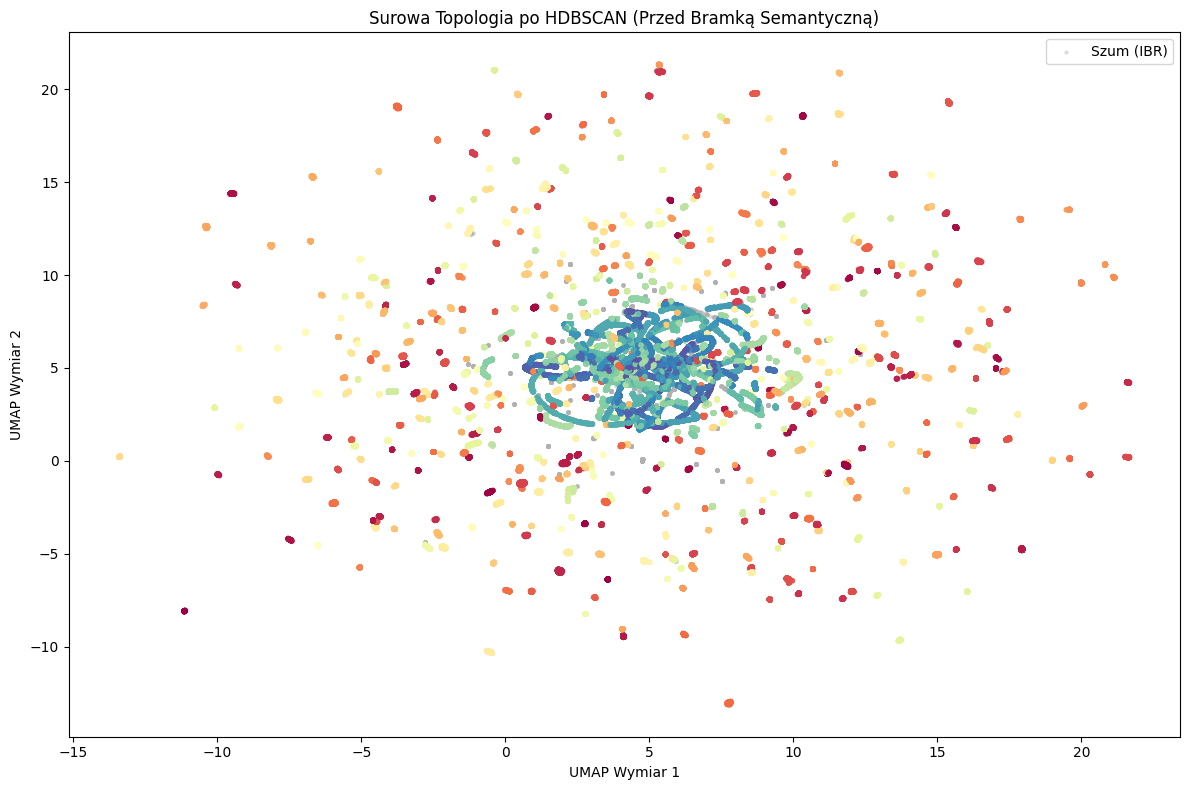


EWALUACJA SPÓJNOŚCI WEWNĘTRZNEJ (INTRA-CLUSTER CONSISTENCY)
KLASTER   | ROZMIAR  | PORT (ZGODNOŚĆ)    | PROTOKÓŁ        | STAN (ZGODNOŚĆ)    | HOMOG %   | DOMINANTA L7 (PAYLOAD)
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
#809      | 573      | 50802 (2.8%)       | TCP (100.0%)    | SR_RA (100.0%)     |  67.60% | [Brak ładunku]
#952      | 558      | 2376 (2.9%)        | TCP (100.0%)    | SR_RA (99.8%)      |  67.56% | [Brak ładunku]
#820      | 538      | 445 (77.0%)        | TCP (100.0%)    | S_RA (96.3%)       |  91.08% | [Brak ładunku]
#569      | 515      | 60001 (8.3%)       | TCP (100.0%)    | S_RA (100.0%)      |  69.45% | [Brak ładunku]
#864      | 391      | 3342 (0.5%)        | TCP (100.0%)    | SR_RA (100.0%)     |  66.84% | [Brak ładunku]
#684      | 378      | 8080 (100.0%)      | TCP (100.0%)    | SR_RA (100.0%)     | 100.00% | [Brak ładunku]
#438   

In [4]:
import hdbscan
import time
import pandas as pd
import numpy as np

print("="*80)
print(">>> KROK 2: HDBSCAN - CONSTRAINED HYBRID LABELING <<<")
print("="*80)

# ==========================================
# 1. KLASTROWANIE HDBSCAN
# ==========================================
start_time = time.time()
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50, 
    min_samples=30, 
    metric='euclidean', 
    cluster_selection_method='eom', 
    core_dist_n_jobs=1, 
    prediction_data=True,
    gen_min_span_tree=True,
    approx_min_span_tree=True
)
hdb_labels = clusterer.fit_predict(X_train_umap)
hdb_probs = clusterer.probabilities_ # Wymagane dla rdzeni (Exemplars)
print(f"[*] HDBSCAN zakończony w {time.time() - start_time:.2f} s.")

df_hdbscan = df_train_eng.copy() 
df_hdbscan['Cluster'] = hdb_labels
df_hdbscan['Cluster_Prob'] = hdb_probs

# =========================================================================
# WIZUALIZACJA I INSPEKCJA SUROWYCH KLASTRÓW (PRZED BRAMKĄ SEMANTYCZNĄ)
# =========================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("\n[*] Generowanie mapy topologicznej UMAP...")
plt.figure(figsize=(12, 8))

# Szum malujemy na szaro i dajemy pod spód (zorder=1, alpha=0.3)
mask_noise = (hdb_labels == -1)
plt.scatter(X_train_umap[mask_noise, 0], X_train_umap[mask_noise, 1], 
            c='#B0B0B0', s=5, alpha=0.3, label='Szum (IBR)', zorder=1)

# Klastry (sygnał) malujemy na kolorowo na wierzchu (zorder=2)
mask_signal = (hdb_labels != -1)
plt.scatter(X_train_umap[mask_signal, 0], X_train_umap[mask_signal, 1], 
            c=hdb_labels[mask_signal], cmap='Spectral', s=10, alpha=0.9, zorder=2)

plt.title("Surowa Topologia po HDBSCAN (Przed Bramką Semantyczną)")
plt.xlabel("UMAP Wymiar 1")
plt.ylabel("UMAP Wymiar 2")
plt.legend()
plt.tight_layout()

# --- ZAPIS WYKRESU DO FOLDERU ---
wykresy_dir = '../wykresy'
if not os.path.exists(wykresy_dir):
    os.makedirs(wykresy_dir)

save_path = os.path.join(wykresy_dir, '01_umap_hdbscan_raw.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"[+] Zapisano wykres w wysokiej rozdzielczości: {save_path}")

plt.show()

# =========================================================================
# WIZUALIZACJA I PASZPORT SUROWYCH KLASTRÓW (PRZED HEURYSTYKĄ)
# =========================================================================

def print_raw_passport(df, title="EWALUACJA SPÓJNOŚCI WEWNĘTRZNEJ (INTRA-CLUSTER CONSISTENCY)"):
    def get_dominance_report(x):
        clean_x = x.dropna()
        if clean_x.empty or (clean_x.astype(str).str.strip() == "").all():
            return "N/A", 0.0
        val_counts = clean_x.value_counts(normalize=True)
        return val_counts.index[0], val_counts.iloc[0] * 100

    df_signal = df[df['Cluster'] != -1].copy()
    clusters = sorted(df_signal['Cluster'].unique())
    
    results = []
    for cluster_id in clusters:
        c_df = df_signal[df_signal['Cluster'] == cluster_id]
        
        # Wyciąganie dominant i ich zgodności procentowej
        port, port_acc = get_dominance_report(c_df['Dport'])
        proto, proto_acc = get_dominance_report(c_df['Proto'])
        state, state_acc = get_dominance_report(c_df['State'])
        
        # Obsługa Payloadu
        has_pay = False
        pay_str, pay_acc = "N/A", 0.0
        if 'srcUdata' in c_df.columns:
            raw_pay, pay_acc = get_dominance_report(c_df['srcUdata'])
            if raw_pay != "N/A":
                has_pay = True
                pay_str = str(raw_pay).replace('\n', ' ').replace('\r', ' ')[:45] + "..."

        # Średnia homogeniczności klastra
        features_acc = [port_acc, state_acc, proto_acc]
        if has_pay: 
            features_acc.append(pay_acc)
        avg_homogeneity = np.mean(features_acc)

        # Oczyszczanie formatu portu
        try:
            port_clean = str(int(float(port))) if port != "N/A" else "N/A"
        except:
            port_clean = str(port)

        results.append({
            'ID': int(cluster_id),
            'Size': len(c_df),
            'Port_Info': f"{port_clean} ({port_acc:.1f}%)",
            'Proto_Info': f"{str(proto).upper()} ({proto_acc:.1f}%)",
            'State_Info': f"{str(state)} ({state_acc:.1f}%)",
            'HMG': avg_homogeneity,
            'Payload_Info': f"{pay_str} ({pay_acc:.1f}%)" if has_pay else "[Brak ładunku]"
        })

    report = pd.DataFrame(results).sort_values(by='Size', ascending=False)

    # Rysowanie estetycznej tabeli
    print("\n" + "="*165)
    print(f"{title}")
    print("="*165)
    header = f"{'KLASTER':<9} | {'ROZMIAR':<8} | {'PORT (ZGODNOŚĆ)':<18} | {'PROTOKÓŁ':<15} | {'STAN (ZGODNOŚĆ)':<18} | {'HOMOG %':<9} | {'DOMINANTA L7 (PAYLOAD)'}"
    print(header)
    print("-" * 165)

    for _, row in report.iterrows():
        print(f"#{row['ID']:<8} | {row['Size']:<8} | {row['Port_Info']:<18} | {row['Proto_Info']:<15} | {row['State_Info']:<18} | {row['HMG']:>6.2f}% | {row['Payload_Info']}")
    
    print("="*165)
    print("[*] UWAGA: HOMOG % (Homogeniczność) określa średnią spójność cech fizycznych wewnątrz klastra.")
    print("           Wyniki > 90% stanowią twardy, matematyczny dowód na prawidłowe wyizolowanie kampanii sieciowej.")


# Wywołanie
print_raw_passport(df_hdbscan)

models_dir = '../modele'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

# Zapisujemy wyuczony hdbscan
joblib.dump(clusterer, os.path.join(models_dir, 'hdbscan_model.pkl'))
print(f"\n[+] Zapisano model HDBSCAN (prediction_data=True) w: {models_dir}/hdbscan_model.pkl")


# # =========================================================================
# # 2. ZEWNĘTRZNA WALIDACJA CTI (ABUSEIPDB) NA TOP 3 KLASTRACH
# # =========================================================================
# import requests
# import time
# import pandas as pd
# import numpy as np

# print("\n" + "="*80)
# print(">>> CTI PROXY VALIDATOR: ŚLEPA WALIDACJA TOP 3 KLASTRÓW (ABUSEIPDB) <<<")
# print("="*80)

# ip_col = next((c for c in ['SrcIP', 'sIP', 'SrcAddr', 'src_ip'] if c in df_hdbscan.columns), None)

# if not ip_col:
#     print("[-] UWAGA: Nie znaleziono kolumny z adresem IP ('SrcIP', 'sIP' itp.).")
# else:
#     ABUSE_KEY = 'ce662d892518c74d2d84b173714dfc35c99c89691dae710ac177fbaf2aaabc8e1440c9ed7651c597'  # <--- WPISZ SWÓJ KLUCZ!
    
#     valid_clusters = df_hdbscan[df_hdbscan['Cluster'] != -1]
    
#     if valid_clusters.empty:
#         print("[-] HDBSCAN nie wykrył żadnych klastrów sygnału.")
#     else:
#         # Wybieramy 3 NAJWIĘKSZE klastry
#         top_clusters = valid_clusters['Cluster'].value_counts().head(3).index.tolist()
#         print(f"[*] Obiekty badawcze: Surowe Klastry {top_clusters}\n")
        
#         url = 'https://api.abuseipdb.com/api/v2/check'
#         headers = {'Accept': 'application/json', 'Key': ABUSE_KEY}
        
#         for target_cluster in top_clusters:
#             print(f">>> TESTOWANIE KLASTRA #{target_cluster} <<<")
            
#             # Ekstrakcja rdzenia (Probability > 0.95) i losowych 3 IP
#             core_ips = valid_clusters[
#                 (valid_clusters['Cluster'] == target_cluster) & 
#                 (valid_clusters['Cluster_Prob'] > 0.95)
#             ][ip_col].dropna().unique()
            
#             if len(core_ips) > 0:
#                 np.random.seed(42)
#                 sample_ips = np.random.choice(core_ips, size=min(3, len(core_ips)), replace=False)
                
#                 results = []
#                 malicious_count = 0
                
#                 for ip in sample_ips:
#                     try:
#                         res = requests.get(url, headers=headers, params={'ipAddress': ip, 'maxAgeInDays': '90'})
#                         if res.status_code == 200:
#                             data = res.json()['data']
#                             score = data['abuseConfidenceScore']
#                             if score > 80: malicious_count += 1
#                             results.append({'IP': ip, 'Confidence (%)': score, 'Zgłoszenia': data.get('totalReports', 0)})
#                         elif res.status_code == 429:
#                             print(f"[-] Przekroczono limit API dla IP {ip}!")
#                     except Exception as e:
#                         print(f"[-] Błąd połączenia: {e}")
#                     time.sleep(0.5) 
                
#                 # Wynik Purity Rate dla danego klastra
#                 if results:
#                     df_cti = pd.DataFrame(results)
#                     purity = (malicious_count / len(results)) * 100
#                     print(df_cti.to_string(index=False))
#                     print(f"[+] Purity Rate dla Klastra #{target_cluster}: {purity:.2f}%\n")
                    
#             else:
#                 print(f"[-] Brak twardego rdzenia w Klastrze #{target_cluster}.\n")
                
#         print("="*80)
#         print("[*] WNIOSKI NAUKOWE DLA PRACY MAGISTERSKIEJ:")
#         print("    - Klastry z Purity 100% oznaczają tzw. Persistent Threats (Trwałą infrastrukturę).")
#         print("    - Klastry z Purity 0% to matematyczny dowód na zjawisko IP Churn (IoC Decay)")
#         print("      i rotację adresów w węzłach dynamicznych (np. wymarłe botnety IoT z 2021 r.).")
#         print("="*80)

### Konfiguracja klastrowania i hybrydowa propagacja etykiet <span style="font-size: 18px;"> 

W tym etapie proces grupowania ruchu realizowany jest przy użyciu algorytmu HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise). Wybór tego algorytmu podyktowany jest jego zdolnością do wykrywania klastrów o dowolnym kształcie oraz natywnej izolacji szumu informacyjnego.
Kluczowe parametry konfiguracyjne:
- <span style="color: red;">min_cluster_size=50:</span> Przyjęto założenie, że statystycznie istotna kampania ataku w logach honeypota musi generować minimum 50 zdarzeń. Pozwala to na odseparowanie zorganizowanych działań od incydentalnych anomalii.
- <span style="color: red;"> min_samples=30: </span> Parametr ten wymusza wysoką gęstość klastrów, co ogranicza ryzyko łączenia odrębnych zachowań sieciowych w jedną strukturę (tzw. ochrona przed zjawiskiem chaining).
- <span style="color: red;"> cluster_selection_method='eom' </span> (Excess of Mass): Zapewnia stabilność klastrów poprzez wybór struktur o największej masie gęstości, co zapobiega nadmiernej fragmentacji dużych, jednorodnych kampanii skanowania.

Constrained Exemplar-based Labeling
Zaimplementowany został autorski, hybrydowy system etykietowania, składający się z trzech filarów bezpieczeństwa

- Exemplar Extraction (Wyodrębnienie Rdzenia): Zamiast patrzeć na cały (często zaszumiony na obrzeżach) klaster, algorytm izoluje 15% punktów o najwyższym prawdopodobieństwie przynależności (HDBSCAN probabilities_). Stanowią one sterylny, matematyczny archetyp ataku
- Cluster Purity Check (Kontrola Czystości): Algorytm sprawdza, czy rdzeń jest jednorodny. Jeśli wewnątrz rdzenia zgadza się mniej niż 70% etykiet fizycznych, klaster zostaje uznany za sztucznie sklejony przez UMAP i otrzymuje flagę MIXED_CLUSTER.
- Semantic Gate (Bramka Semantyczna): To najważniejszy element mechanizmu. Zanim wiersz odziedziczy etykietę od klastra, następuje twarda weryfikacja. Fizyczny port wiersza musi zgadzać się z usługą proponowaną przez klaster. Jeśli UMAP spróbuje narzucić etykietę "DNS" pakietowi lecącemu na port 80, Bramka Semantyczna to zablokuje i wymusi powrót do prawdy fizycznej (Row-by-Row fallback).</span>

# Pseudo-Labeling | Profilowanie

In [9]:
# ==========================================
# 1. DEFINICJA HEURYSTYKI BAZOWEJ
# ==========================================
SERVICE_MAP = {
    # --- 1. Usługi Klasyczne / Podstawowe ---
    19: 'CHARGEN', 20: 'FTP_Data', 21: 'FTP', 22: 'SSH', 23: 'Telnet', 
    25: 'SMTP', 53: 'DNS', 80: 'HTTP', 110: 'POP3', 
    111: 'RPCbind', 123: 'NTP', 143: 'IMAP', 443: 'HTTPS',

    # --- 2. Bezpieczna Poczta i Active Directory ---
    88: 'Kerberos', 465: 'SMTPS', 587: 'SMTP_Submission', 
    636: 'LDAPS', 993: 'IMAPS', 995: 'POP3S', 5355: 'LLMNR',

    # --- 3. Ekosystem Windows / SMB ---
    135: 'MSRPC', 137: 'NetBIOS_NS', 138: 'NetBIOS_DGM', 139: 'NetBIOS_SSN', 
    445: 'SMB', 3389: 'RDP', 5985: 'WinRM_HTTP', 5986: 'WinRM_HTTPS',

    # --- 4. Bazy Danych, Wirtualizacja i Big Data ---
    902: 'VMware_ESXi', 1433: 'MSSQL', 1521: 'Oracle_DB', 3306: 'MySQL', 
    5432: 'PostgreSQL', 5984: 'CouchDB', 6379: 'Redis', 
    9200: 'Elasticsearch', 27017: 'MongoDB',

    # --- 5. Chmura, Kubernetes i Narzędzia Webowe ---
    2375: 'Docker_API_HTTP', 2376: 'Docker_API_HTTPS', 
    2379: 'etcd_Client', 2380: 'etcd_Peer', 8500: 'Consul',
    6443: 'Kubernetes_API', 10250: 'Kubelet',
    8080: 'HTTP_Alt', 8081: 'HTTP_Alt_2', 8443: 'HTTPS_Alt', 8888: 'HTTP_Alt_Admin',
    9000: 'Portainer/SonarQube',

    # --- 6. Observability (Monitoring i Logi) ---
    3000: 'Grafana', 5044: 'Logstash', 5601: 'Kibana',
    9090: 'Prometheus_API', 9091: 'Prometheus_Pushgateway', 
    9093: 'Alertmanager', 9100: 'Node_Exporter',
    14268: 'Jaeger_Collector', 16686: 'Jaeger_UI',

    # --- 7. Wektory Amplifikacji DDoS (UDP Reflection) ---
    17: 'QOTD', 161: 'SNMP', 389: 'LDAP', 
    500: 'ISAKMP_VPN', 1900: 'SSDP', 3702: 'WS-Discovery', 
    5353: 'mDNS', 5683: 'CoAP', 11211: 'Memcached',

    # --- 8. IoT, Routery i Protokoły Bezpieczne ---
    69: 'TFTP',1080: 'SOCKS_Proxy', 2323: 'Telnet_IoT_Alt', 3128: 'Squid_Proxy', 
    4500: 'IPsec_NAT_T', 5060: 'SIP', 5061: 'SIP_TLS', 5070: 'SIP_Alt',
    51820: 'WireGuard_VPN', 5555: 'Android_ADB', 5671: 'AMQPS', 
    5900: 'VNC', 7547: 'TR-069_CWMP', 8291: 'MikroTik_Winbox', 
    8883: 'MQTT_Secure', 37215: 'Huawei_Router_UPnP', 52869: 'Realtek_Router',
    53413: 'Netis_Router',

    # --- 9. Klasyczne Malware, Botnety i C2 ---
    4444: 'Metasploit_RevShell', 6667: 'IRC_Botnet', 31337: 'BackOrifice_Elite',

    623: 'IPMI',
    1194: 'OpenVPN',
    1434: 'MSSQL_Resolution',
    6881: 'BitTorrent',
    8889: 'HTTP_Alt_Admin'
}

def safe_port_convert(port_val):
    try:
        # Obsługa wartości heksadecymalnych (np. '0x0800' lub '0X0008')
        if isinstance(port_val, str) and str(port_val).lower().startswith('0x'):
            return int(port_val, 16)
        return int(float(port_val))
    except (ValueError, TypeError):
        return -1

def get_label_for_row(row):
    port = safe_port_convert(row['Dport'])
    proto = str(row['Proto']).lower()
    state = str(row.get('State', ''))
   
    # Odzyskanie surowej fizyki
    pkts = int(np.expm1(float(row['TotPkts']))) if row['TotPkts'] > 0 else 0
    bpp  = float(np.expm1(float(row['Bytes_per_Pkt']))) if row['Bytes_per_Pkt'] > 0 else 0
    dur  = float(np.expm1(float(row['Dur']))) if row['Dur'] > 0 else 0
   
    # Pobranie nazwy usługi ze SERVICE_MAP (to jest jedyne miejsce z portami!)
    service = SERVICE_MAP.get(port, f"{proto.upper()}_Port_{port}" if port != -1 else "GENERIC")
   
    # === 1. ZŁOTE REGUŁY PROTOKOLARNE (niezależne od portu) ===
    if proto == 'icmp' or state == 'ECO':
        return "ICMP Fingerprinting (OS Detection)"
   
    # === 2. MASS TCP SCAN (najważniejsza reguła – pierwsza!) ===
    if proto == 'tcp' and pkts <= 5 and bpp <= 65:
        return "Mass TCP Port Scanning (L4)"
   
    # === 3. HIGH-PORT UDP PROBE (teraz bez twardych wyjątków!) ===
    # Tylko UDP + bardzo mało pakietów + port > 1024 + NIE jest to znana usługa
    if (proto == 'udp' and 
        pkts <= 2 and 
        bpp <= 65 and 
        port > 1024 and 
        service.startswith(proto.upper() + "_Port_")):   # <-- klucz: jeśli SERVICE_MAP nie nadał własnej nazwy
        return "High-Port UDP Probe"
   
    # === 4. KLASYCZNE ZJAWISKA (dla ruchu, który nie jest prostym skanem) ===
    if dur > 60 and pkts < 20:
        return "Long-lived Session / C2 Beaconing"
   
    if pkts > 15 and dur > 1.0:
        return f"{service} Brute Force"
   
    # === 5. DOMYŚLNA ENUMERACJA ===
    return f"{service} Enumeration"

# ==========================================
# 2. CONSTRAINED EXEMPLAR-BASED LABEL PROPAGATION
# ==========================================
print("[*] Rozpoczynanie hybrydowej propagacji etykiet (Constrained Pseudo-Labeling)...")

unique_clusters = set(hdb_labels) - {-1}
cluster_label_map = {}

for cluster_id in unique_clusters:
    # A. Izolacja klastra
    cluster_points = df_hdbscan[df_hdbscan['Cluster'] == cluster_id]
    
    # B. Wyodrębnienie rdzenia (Exemplars)
    top_quantile = cluster_points['Cluster_Prob'].quantile(0.85)
    exemplars = cluster_points[cluster_points['Cluster_Prob'] >= top_quantile]
    
    # C. Głosowanie w rdzeniu
    candidate_labels = exemplars.apply(get_label_for_row, axis=1)
    label_counts = candidate_labels.value_counts(normalize=True)
    
    winning_label = label_counts.index[0]
    purity = label_counts.iloc[0]
    
    # D. Weryfikacja czystości semantycznej klastra (>70% spójności)
    if purity >= 0.70:
        cluster_label_map[cluster_id] = winning_label
    else:
        cluster_label_map[cluster_id] = "MIXED_CLUSTER"


PROB_THRESHOLD = 0.85  # Zgodnie z wytycznymi z raportu dla SemanticGate

def apply_constrained_label(row):
    # 1. Zwykły szum z HDBSCAN
    if row['Cluster'] == -1:
        return 'Background Noise'
        
    # 2. ODRZUCENIE RUBIEŻY (Zgodnie z koncepcją SeCo)
    # Jeśli wektor jest na skraju klastra (niska pewność HDBSCAN), nie ufamy mu.
    if row.get('Cluster_Prob', 1.0) < PROB_THRESHOLD:
        return 'UNKNOWN_OR_NOISE'
        
    cluster_proposed_label = cluster_label_map.get(row['Cluster'], 'Unclassified')
    row_physical_label = get_label_for_row(row)
    
    if cluster_proposed_label == "MIXED_CLUSTER":
        return row_physical_label
        
    # BRAMKA SEMANTYCZNA (Semantic Gate)
    proposed_service = cluster_proposed_label.split()[0]
    physical_service = row_physical_label.split()[0]
    
    if proposed_service == physical_service:
        return cluster_proposed_label
    else:
        return 'VETOED_BY_GATE'

df_hdbscan['Refined_Label'] = df_hdbscan.apply(apply_constrained_label, axis=1)

# WYŚWIETLENIE STATYSTYK BRAMKI DLA PRACY MAGISTERSKIEJ
veto_count = (df_hdbscan['Refined_Label'] == 'VETOED_BY_GATE').sum()
unknown_count = (df_hdbscan['Refined_Label'] == 'UNKNOWN_OR_NOISE').sum()
print(f"[*] Semantic Gate (SeCo): Odrzucono {veto_count} wektorów sprzecznych fizycznie (VETO).")
print(f"[*] Semantic Gate (SeCo): Odrzucono {unknown_count} wektorów granicznych (Chaos Reduction).")


[*] Rozpoczynanie hybrydowej propagacji etykiet (Constrained Pseudo-Labeling)...
[*] Semantic Gate (SeCo): Odrzucono 186 wektorów sprzecznych fizycznie (VETO).
[*] Semantic Gate (SeCo): Odrzucono 34274 wektorów granicznych (Chaos Reduction).


# Walidacja | Deep Packet Inspection

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import umap.umap_ as umap
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
import os
import random

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

print("="*80)
print(">>> KROK 2.5: WSTĘPNA WALIDACJA MODELU (PRZED REKURENCJĄ) <<<")
print("="*80)

print_traffic_passport(df_hdbscan, title="PASZPORT RUCHU (PRZED REKURENCJNYM KLASTROWANIEM)")

# ==========================================
# 2. MASTER VALIDATION SUITE
# ==========================================

def run_full_validation_suite(df_analyzed, X_geom, clusterer_obj, label_col='Refined_Label', min_plot_records=10, sample_size=15000, output_dir='../wykresy'):
    print(f"\n##########################################################")
    print(f"###                 Walidacja modelu                   ###")
    print(f"##########################################################\n")
    
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # 1. PRZYGOTOWANIE DANYCH (Zabezpieczenie Indeksów)
    df = df_analyzed.copy().reset_index(drop=True)
    df[label_col] = df[label_col].astype(str)
    
    # --- ODWROTNOŚĆ LOGARYTMÓW DO WYKRESÓW BOXPLOT (Critical Fix) ---
    for col in ['Dur', 'TotBytes']:
        if col in df.columns:
            df[f'{col}_real'] = np.expm1(df[col]).clip(lower=0)
    
    # 2. INTELIGENTNE GRUPOWANIE DŁUGIEGO OGONA (Tylko dla wykresów!)
    class_counts = df[label_col].value_counts()
    valid_classes = class_counts[class_counts >= min_plot_records].index
    
    df['Plot_Label'] = df[label_col].apply(lambda x: x if x in valid_classes else 'Minor Anomalies')
    df['Plot_Label'] = df['Plot_Label'].replace('Background Noise', 'Noise')

    # 3. KOLORYSTYKA
    unique_labels = sorted([l for l in df['Plot_Label'].unique() if l not in ['Noise', 'Minor Anomalies']])
    n_labels = len(unique_labels)
    palette_raw = sns.color_palette("husl", n_labels)
    random.seed(42)
    
    color_dict = dict(zip(unique_labels, palette_raw))
    color_dict['Noise'] = '#B0B0B0'
    color_dict['Minor Anomalies'] = '#000000'
    
    hue_order = unique_labels + ['Minor Anomalies', 'Noise']
    # --- [A] METRYKI WEWNĘTRZNE ---
    print(">>> [A] OBLICZANIE METRYK WEWNĘTRZNYCH (HDBSCAN)...")
    labels_raw = df['Cluster'].values
    mask = labels_raw != -1
    X_clean = X_geom[mask]
    y_clean = labels_raw[mask]
    
    metrics_text = ""
    if len(set(y_clean)) < 2:
        metrics_text = "Za mało klastrów do oceny."
    else:
        # =========================================================
        # 1. METRYKI ODLEGŁOŚCIOWE (Robimy na próbce, żeby oszczędzić RAM)
        # =========================================================
        sample_size = 20000 # Możesz dostosować tę wartość
        if len(X_clean) > sample_size:
            idx = np.random.choice(len(X_clean), sample_size, replace=False)
            X_samp, y_samp = X_clean[idx], y_clean[idx]
        else:
            X_samp, y_samp = X_clean, y_clean
    
        sil = silhouette_score(X_samp, y_samp)
        db = davies_bouldin_score(X_samp, y_samp)
        metrics_text += f"Silhouette Score (próbka {len(X_samp)}): {sil:.4f}\n"
        metrics_text += f"Davies-Bouldin   (próbka {len(X_samp)}): {db:.4f}\n"
    
        # =========================================================
        # 2. METRYKA GĘSTOŚCIOWA - DBCV 
        # =========================================================
        try:
            if hasattr(clusterer, 'relative_validity_') and clusterer.relative_validity_ is not None:
                # Dla porównania hiperparametrów – bierzemy z modelu (już policzone na próbce w grid search)
                dbc_score = clusterer.relative_validity_
                metrics_text += f"DBCV (przybliżenie na próbce {len(X_clean)}): {dbc_score:.4f}\n"
            else:
                metrics_text += "DBCV: Model uruchomiony bez gen_min_span_tree=True\n"
        except:
            metrics_text += "DBCV: niedostępne (użyj próbki 20-30k w grid search)\n"
            
    print(metrics_text)

    # --- [B] HISTOGRAM PEWNOŚCI ---
    print(">>> [B] GENEROWANIE HISTOGRAMU PEWNOŚCI...")
    probs = clusterer_obj.probabilities_
    mask_noise = labels_raw == -1
    plt.figure(figsize=(10, 5))
    plt.hist(probs[~mask_noise], bins=40, color='forestgreen', alpha=0.7, label='Zdefiniowane Klastry', density=True)
    plt.hist(probs[mask_noise], bins=40, color='firebrick', alpha=0.7, label='Szum HDBSCAN', density=True)
    plt.title("Jakość Separacji: Histogram Pewności Modelu", fontsize=12)
    plt.legend()
    plt.savefig(os.path.join(output_dir, '03_probability_histogram.png'), bbox_inches='tight')
    plt.close()

    # --- [C] DRZEWO SKONDENSOWANE (HDBSCAN) ---
    print(">>> [D] GENEROWANIE DRZEWA SKONDENSOWANEGO HDBSCAN...")
    plt.figure(figsize=(12, 8))
    
    try:
        clusterer.condensed_tree_.plot(
            select_clusters=True, 
            selection_palette=sns.color_palette('tab20', len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0))
        )
        plt.title('Hierarchia gęstości HDBSCAN (Condensed Tree)', fontsize=15)
        plt.ylabel('Lambda (Miara gęstości / 1/distance)', fontsize=12)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, '04_hdbscan_condensed_tree.png'), bbox_inches='tight')
        plt.close()
        print("[+] SUKCES: Wykres Condensed Tree został zapisany!")
    except Exception as e:
        print(f"[-] BŁĄD przy generowaniu Condensed Tree: {e}. Sprawdź nazwę zmiennej modelu HDBSCAN.")
    
    # --- [D] KORELACJE ---
    print(">>> [G] OBLICZANIE MACIERZY KORELACJI...")
    cols_corr = ['Dur', 'TotPkts', 'TotBytes', 'Bytes_per_Pkt', 'Load', 'Rate', 'SrcPkts', 'DstPkts', 'pLoss']
    cols_exist = [c for c in cols_corr if c in df.columns]
    
    numeric_df = df[cols_exist].copy()
    corr = numeric_df.corr(method='spearman')
    mask_tri = np.triu(np.ones_like(corr, dtype=bool))
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, mask=mask_tri, cmap='coolwarm', vmax=1.0, vmin=-1.0, center=0,
                square=True, linewidths=.5, annot=True, fmt=".2f", cbar_kws={"shrink": .8})
    plt.title("Macierz Korelacji Cech Sieciowych", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, '05_correlation_matrix.png'), bbox_inches='tight')
    plt.close()
    
    print(f"\n[SUKCES] Komplet wszystkich 3 zestawów wizualizacji zapisany w folderze '{output_dir}'.")

# URUCHOMIENIE WALIDACJI (Tu wstawiasz gotowy zbiór, np. przed Długim Ogonem)
run_full_validation_suite(df_hdbscan, X_train_umap, clusterer, label_col='Refined_Label')

>>> KROK 2.5: WSTĘPNA WALIDACJA MODELU (PRZED REKURENCJĄ) <<<

PASZPORT RUCHU (PRZED REKURENCJNYM KLASTROWANIEM)
KLASA (Refined_Label)                | LICZNOŚĆ  | PORT   | PKT    | BpP      | STATE  | PRÓBKA PAYLOADU (DOMINANTA)
---------------------------------------------------------------------------------------------------------------------------------------
Mass TCP Port Scanning (L4)          | 72676     | 25     | 2      | 59.0     | S_RA   | s[6]=...... (100.0%)
UNKNOWN_OR_NOISE                     | 34274     | 25     | 2      | 61.8     | S_RA   | s[99]=M-SEARCH * HTTP/1.1..Hos... (2.5%)
OTHER_Port_0 Enumeration             | 11439     | 0      | 2      | 59.8     | NAN    | s[48]='..<....l..z...$>.1........ (3.4%)
Background Noise                     | 5642      | 0      | 3      | 63.1     | SR_RA  | s[54]=........................... (12.8%)
ICMP Fingerprinting (OS Detection)   | 4434      | 0      | 2      | 94.4     | ECO    | s[14]=...........G@ (0.2%)
0X0008_Port_0 Enu

<span style="font-size: 18px;"> Automatyczna walidacja oceniająca jakość klastrowania. Generujemy zestaw metryk wewnętrznych (Silhouette, DBCV, Davies-Bouldin) oraz 7 wizualizacji (m.in. mapy topologii UMAP, sygnatury wolumetryczne w postaci wykresów pudełkowych, heatmapy stanów TCP). Pozwala to na fizyczną weryfikację, czy wydzielone klastry faktycznie reprezentują odmienne typy zachowań sieciowych adwersarzy. </span>

# Recursive Noise Mining | Final Correction

In [13]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import umap.umap_ as umap
import hdbscan
import os

print("="*80)
print(">>> KROK 3: REKURENCYJNE KLASTROWANIE SZUMU (NOISE MINING) <<<")
print("="*80)

noise_labels = ['Background Noise', 'UNKNOWN_OR_NOISE', 'VETOED_BY_GATE']
df_noise = df_hdbscan[df_hdbscan['Refined_Label'].isin(noise_labels)].copy()
df_final = df_hdbscan.copy() # Baza, na której będziemy pracować do samego końca

# BEZPIECZNIK: Jeśli nie ma szumu, pomijamy ten krok
if len(df_noise) < 15: 
    print(f"[*] Zbyt mała ilość szumu do klastrowania ({len(df_noise)} rekordów). Pomijam Noise Mining.")
else:
    print(f"[*] Wyizolowano {len(df_noise)} rekordów szumu i odrzutów SeCo. Eksploracja...")

    # Przygotowanie i skalowanie szumu (Lokalna struktura)
    features_to_use = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts']
    if 'Bytes_per_Pkt' in df_noise.columns: features_to_use.append('Bytes_per_Pkt')
    
    X_noise_scaled = StandardScaler().fit_transform(df_noise[features_to_use].fillna(0).values)

    reducer_noise = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.01, random_state=42, n_jobs=1)
    X_noise_umap = reducer_noise.fit_transform(X_noise_scaled)
    
    clusterer_noise = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5, metric='euclidean', cluster_selection_method='eom')
    df_noise['Sub_Cluster'] = clusterer_noise.fit_predict(X_noise_umap)

    df_noise['Sub_Cluster_Prob'] = clusterer_noise.probabilities_
    
    unique_micro_clusters = df_noise['Sub_Cluster'].nunique() - 1
    print(f"[*] Odkryto {unique_micro_clusters} nowych mikrogrup w obrębie szumu.")

    def map_noise_micro_clusters(row):
        if row['Sub_Cluster'] == -1 or row['Sub_Cluster_Prob'] < 0.85: 
            return "Background Noise"
        return get_label_for_row(row) 

    df_noise['Final_Refined_Label'] = df_noise.apply(map_noise_micro_clusters, axis=1)

    # Scalenie z głównym zbiorem
    df_final.loc[df_noise.index, 'Refined_Label'] = df_noise['Final_Refined_Label']

# ==========================================
# 2. OSTATECZNA KOREKTA SEMANTYCZNA
# ==========================================

def semantic_ground_truth_correction(row):
    label = str(row['Refined_Label'])

    # BEZPIECZNIK BRAMKI SEMANTYCZNEJ (SeCo)
    if label in ['Background Noise', 'UNKNOWN_OR_NOISE', 'VETOED_BY_GATE']:
        return label
    
    port = safe_port_convert(row['Dport'])
    payload = str(row.get('srcUdata', '')).lower()
   
    if label == 'HTTP Enumeration' and port == 111 and 'objectclass' in payload:
        return 'LDAP Enumeration'
   
    elif 'get /' in payload and 'http' in payload and port not in [80, 443, 8080, 8081, 8443, 8888]:
        return 'HTTP Cross-Protocol Anomaly'
   
    elif 'm-search' in payload:
        return 'SSDP/UPnP Amplification Recon'
   
    elif port == 53413 and ('cd /tmp' in payload or 'cd /var' in payload):
        return 'Mirai/Netis Command Injection'
   
    elif port == 137 and 'ckaaaaaaaa' in payload:
        return 'NetBIOS_NS Enumeration'
   
    elif port == 19 and len(payload.replace('\n', '').strip()) == 1:
        return 'CHARGEN Amplification Recon'
   
    elif label == 'HTTP Anomaly' and '[brak payloadu]' in payload:
        return 'Mass TCP Port Scanning (L4)'
   
    elif 'Port_0' in label or label.startswith(('0X', '0x')):
        return 'Non-TCP/UDP Protocol Scan (L3)'
   
    elif port == 47808 and str(row.get('Proto', '')).lower() == 'udp':
        return 'BACnet Enumeration'
   
    return label

df_final['Refined_Label'] = df_final.apply(semantic_ground_truth_correction, axis=1)

# ==========================================
# 3. OCZYSZCZANIE ZBIORU POD ML (Agregacja Długiego Ogona)
# ==========================================
print("\n[*] Przygotowanie finalnego zbioru pod Machine Learning...")

THRESHOLD = 30
class_counts = df_final['Refined_Label'].value_counts()
valid_classes = class_counts[class_counts >= THRESHOLD].index

# Nadpisujemy małe klasy
df_final.loc[~df_final['Refined_Label'].isin(valid_classes), 'Refined_Label'] = 'Rare / Minor Anomalies'

print(f"[*] Skonwertowano małe klastry (poniżej {THRESHOLD} próbek) do grupy 'Rare / Minor Anomalies'.")
print(f"[*] Finalna liczba rekordów gotowych do treningu ML: {len(df_final)}")

# Wyświetlenie ostatecznego rozkładu
print("Rozkład klas po agregacji Długiego Ogona:")
print(df_final['Refined_Label'].value_counts().head(15))
# ==========================================
# 4. WYDRUK I EKSPORT
# ==========================================
print_traffic_passport(df_final, title="OSTATECZNY PASZPORT RUCHU (GOTOWY DO ML)")

print("\n[*] Finalizacja zbioru danych...")

df_ml_final = df_final[df_final['Refined_Label'] != 'Background Noise'].copy()

print(f"[*] Usunięto klasę 'Background Noise' ({len(df_final) - len(df_ml_final)} rekordów).")
print(f"[*] Klasa 'Rare / Minor Anomalies' została zachowana jako wzorzec rzadkich incydentów.")

# Eksport
output_dir_final = '../dane/gotowe_ml/'
if not os.path.exists(output_dir_final): 
    os.makedirs(output_dir_final)

output_file = output_dir_final + 'honeypot_ml_ready.csv'
df_ml_final.to_csv(output_file, index=False)

print(f"\n[SUKCES] Zapisano {len(df_ml_final)} wierszy.")
print(f"[+] Plik sterylny gotowy do modeli ML: {output_file}")

# ==========================================
# 5. OSTATECZNE WIZUALIZACJE (Ewaluacja Zjawisk)
# ==========================================
print("\n" + "="*80)
print(">>> KROK 4: WIZUALIZACJE OPRACOWANEGO ZBIORU (GROUND TRUTH) <<<")
print("="*80)

# Folder na wizualizacje
vis_dir = '../wykresy/'
if not os.path.exists(vis_dir):
    os.makedirs(vis_dir)

# Przygotowanie unikalnych etykiet i palety kolorów
unique_labels = df_final['Refined_Label'].unique().tolist()
if 'Background Noise' in unique_labels: unique_labels.remove('Background Noise')
if 'Rare / Minor Anomalies' in unique_labels: unique_labels.remove('Rare / Minor Anomalies')

# Dynamiczna paleta kolorów
palette = sns.color_palette("husl", len(unique_labels))
color_dict = dict(zip(unique_labels, palette))
color_dict['Rare / Minor Anomalies'] = 'orange'
color_dict['Background Noise'] = 'lightgray'

hue_order = unique_labels + ['Rare / Minor Anomalies', 'Background Noise']

# --- [A] MAPA 2D (UMAP) z ostatecznymi etykietami ---
print(">>> [A] GENEROWANIE OSTATECZNEJ MAPY UMAP 2D...")
# Używamy df_final i zmiennej z klastrowania X_train_umap (lub X_geom, upewnij się jak się nazywa!)
try:
    X_plot = X_train_umap 
    y_plot = df_final['Refined_Label']
    
    plt.figure(figsize=(14, 9))
    sns.scatterplot(x=X_plot[:, 0], y=X_plot[:, 1], hue=y_plot, hue_order=hue_order, palette=color_dict, s=15, alpha=0.8)
    plt.title("Ostateczna Topologia Zagrożeń (UMAP 2D) - Etykiety Semantyczne", fontsize=14)
    plt.legend(bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., fontsize='small', title="Klasa Ataku")
    plt.tight_layout()
    plt.savefig(os.path.join(vis_dir, '06_umap_topology.png'), bbox_inches='tight')
    plt.close()
except NameError:
    print("[-] BŁĄD: Brak zmiennej z wynikami UMAP (X_train_umap lub X_geom). Pomiń ten wykres lub popraw zmienną.")

# --- [B] TIMELINE ---
print(">>> [B] GENEROWANIE TIMELINE (Dynamika)...")
col_time = None
for c in ['StartTime', 'stime', 'ts', 'Time']:
    if c in df_final.columns:
        col_time = c
        break
        
if col_time:
    df_time = df_final.copy()
    df_time['dt'] = pd.to_datetime(df_time[col_time], errors='coerce')
    df_time = df_time.dropna(subset=['dt'])
    df_time_shuffled = df_time.sample(frac=1, random_state=42).reset_index(drop=True)
    
    plt.figure(figsize=(16, 9))
    sns.scatterplot(data=df_time_shuffled, x='dt', y='Refined_Label', hue='Refined_Label', hue_order=hue_order, palette=color_dict, s=30, legend=False, alpha=0.9)
    plt.title("Ostateczna Dynamika Zagrożeń w Czasie", fontsize=14)
    plt.grid(True, alpha=0.4, linestyle='--')
    plt.tight_layout()
    plt.savefig(os.path.join(vis_dir, '07_timeline_analysis.png'), bbox_inches='tight')
    plt.close()
else:
    print("[Warn] Brak kolumny czasu dla Timeline.")

# --- [C] SYGNATURY WIZUALNE (BOXPLOTS) ---
print(">>> [C] GENEROWANIE SYGNATUR (BOXPLOTS)...")
fig, axes = plt.subplots(1, 2, figsize=(18, 8)) 
labels_no_noise = [l for l in hue_order if l != 'Background Noise']

# Zmień 'Dur_real' / 'TotBytes_real' na zwykłe 'Dur' / 'TotBytes', jeśli nie masz odkodowanych
if 'Dur' in df_final.columns:
    sns.boxplot(data=df_final[df_final['Refined_Label'] != 'Background Noise'], x='Refined_Label', y='Dur', hue='Refined_Label', legend=False, ax=axes[0], palette=color_dict, showfliers=False, order=labels_no_noise)
    axes[0].set_title("Sygnatura Czasowa (Duration)", fontsize=12)
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_yscale('log')

if 'TotBytes' in df_final.columns:
    sns.boxplot(data=df_final[df_final['Refined_Label'] != 'Background Noise'], x='Refined_Label', y='TotBytes', hue='Refined_Label', legend=False, ax=axes[1], palette=color_dict, showfliers=False, order=labels_no_noise)
    axes[1].set_title("Sygnatura Wolumetryczna (Bytes)", fontsize=12)
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].set_yscale('log')
    
plt.tight_layout()
plt.savefig(os.path.join(vis_dir, '3_final_signatures.png'), bbox_inches='tight')
plt.close()

# --- [D] HEATMAPA (FINGERPRINTING) ---
print(">>> [D] GENEROWANIE HEATMAPY STANÓW TCP...")
if 'State' in df_final.columns:
    fingerprint = pd.crosstab(df_final['Refined_Label'], df_final['State'], normalize='index')
    top_attacks = df_final['Refined_Label'].value_counts().index
    fingerprint = fingerprint.reindex(top_attacks)
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(fingerprint, cmap='magma_r', linewidths=.5, linecolor='lightgray', annot=False)
    plt.title("Atak vs Stan Połączenia (Fingerprinting Behawioralny)", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(vis_dir, '08_fingerprint_heatmap.png'), bbox_inches='tight')
    plt.close()

print(f"\n[+] Ostateczne wizualizacje zapisane w folderze '{vis_dir}'.")

>>> KROK 3: REKURENCYJNE KLASTROWANIE SZUMU (NOISE MINING) <<<
[*] Wyizolowano 40102 rekordów szumu i odrzutów SeCo. Eksploracja...
[*] Odkryto 827 nowych mikrogrup w obrębie szumu.

[*] Przygotowanie finalnego zbioru pod Machine Learning...
[*] Skonwertowano małe klastry (poniżej 30 próbek) do grupy 'Rare / Minor Anomalies'.
[*] Finalna liczba rekordów gotowych do treningu ML: 133852
Rozkład klas po agregacji Długiego Ogona:
Refined_Label
Mass TCP Port Scanning (L4)           90266
Background Noise                      17558
Non-TCP/UDP Protocol Scan (L3)        15238
ICMP Fingerprinting (OS Detection)     5432
Rare / Minor Anomalies                  918
SIP Enumeration                         677
NTP Enumeration                         496
Long-lived Session / C2 Beaconing       451
ISAKMP_VPN Brute Force                  442
HTTP_Alt_Admin Brute Force              365
High-Port UDP Probe                     332
SSDP/UPnP Amplification Recon           275
LDAP Enumeration            

### Eksploracja szumu (Recursive Noise Mining)<span style="font-size: 18px;"> 

Szum odrzucony w pierwszym przebiegu HDBSCAN (Label -1) może wciąż zawierać celowe, ale rzadkie ataki (np. punktowe uderzenia w nietypowe porty UDP). Aby wyizolować te mikro-anomalie z tła internetowego, zastosowano klastrowanie rekurencyjne o podwyższonej czułości:
- UMAP (min_dist=0.01): Parametr kompresji przestrzennej został ekstremalnie obniżony. Zmusza to algorytm do bardzo ciasnego pakowania identycznych pakietów, uwydatniając małe grupy.
- HDBSCAN (min_cluster_size=15, min_samples=5): Drastyczne obniżenie progów względem głównego modelu. Tym razem szukamy ukrytych mikrogrup (minimum 15 rekordów) i pozwalamy na klastrowanie przy znacznie mniejszej gęstości otoczenia.

Znalezione w ten sposób mikro-anomalie (m.in. SSDP Amplification czy skany DNS) są ponownie mapowane, co ostatecznie domyka proces tworzenia czystego zbioru Ground Truth.<span>
